**Regularization:**
In both cases, we modify the loss function:$$\text{New Loss} = \text{Error (e.g., MSE)} + \lambda \times \text{Penalty}$$The parameter $\lambda$ (lambda) controls the "strength" of the regularization.

1.** L1 Regularization (Lasso)**L1 adds a penalty equal to the absolute value of the magnitude of coefficients.Formula: $\lambda \sum |w_i|$Key Feature: It can push the weights of less important features all the way to zero.Best Use Case: Feature Selection. If you have 100 features but suspect only 10 are actually important, L1 will "zero out" the 90 useless ones, leaving you with a sparse, interpretable model.

2. **L2 Regularization (Ridge)**L2 adds a penalty equal to the square of the magnitude of coefficients.Formula: $\lambda \sum w_i^2$Key Feature: It penalizes large weights heavily but rarely pushes them to exactly zero. Instead, it "decays" them to very small values.Best Use Case: Complex Data. If you have many features that are all slightly related (multicollinearity), L2 will keep all of them but ensure none of them "explode" or dominate the model. It generally provides better prediction accuracy than L1 if all features are somewhat relevant.

its more oveused in regression , deep learning and SVM based models

if your model accuracy is higher in training data and low in test data then its the problem of **overfitting**

**How To encounter:**


1.   Adding More Data.
2.   Reducing the NN architecture
3.   Regularization : we add peanalty in loss. There are two type of Regularization.


*   L1 Regularization:
*   L2 Regularization: in Deep learning, we use mostly this.



4. DropOut : we turn off the neuron randomily.
5. Data Augmentation : changing the scale and rotating the axis, mostly used in CNN
6. Batch normalization:
7. Early Stopping



**Dropout**:
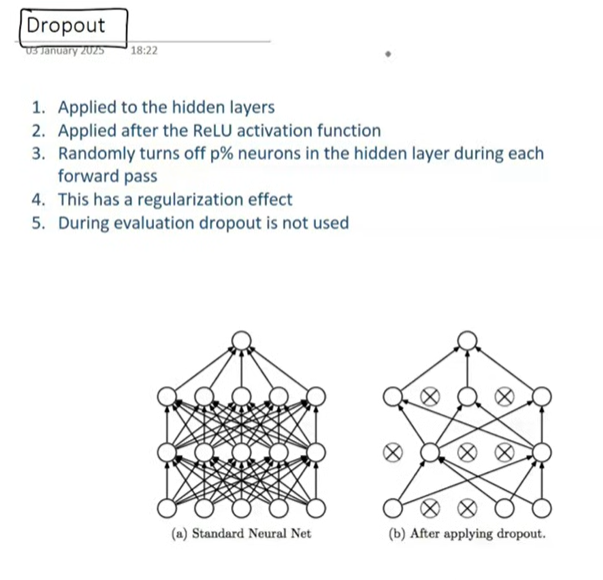

In [53]:
from torch.cuda import is_available
device='cuda' if is_available() else 'cpu'
print(device)

cuda


In [54]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score,roc_curve
import torch
from torch.utils.data import Dataset,DataLoader
import torch.nn as nn
import torch.optim as optim
from matplotlib import pyplot as plt


In [55]:
df=pd.read_csv('fashion-mnist_train.csv')
df.head()

,label,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783,pixel784
0,2,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,9,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,6,0,0,0,0,0,0,0,5,0,...,0,0,0,30,43,0,0,0,0,0
3,0,0,0,0,1,2,0,0,0,0,...,3,0,0,0,0,1,0,0,0,0
4,3,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [56]:
class MyModel(nn.Module):
  def __init__(self,features):
    super().__init__()
    self.container=nn.Sequential(
        nn.Linear(features.shape[1],128),
        nn.BatchNorm1d(128),
        nn.ReLU(),
        nn.Dropout(p=0.3),
        nn.Linear(128,64),
        nn.BatchNorm1d(64), # batch Normalization
        nn.ReLU(),
        nn.Dropout(p=0.3), # drop Outs
        nn.Linear(64,10))

  def forward(self,x):
    return self.container(x)



**Batch Normalization:**


In [57]:
class CustomData(Dataset):
  def __init__(self,x,y):
    super().__init__()
    self.x=torch.from_numpy(x).float()
    self.y=torch.from_numpy(y).long()

  def __len__(self):
    return len(self.y)

  def __getitem__(self,idx):
    return self.x[idx],self.y[idx]

## Train Test split

In [82]:
X = df.iloc[:, 1:].values # converting to numpy array
y = df.iloc[:, 0].values

In [83]:
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [85]:
len(y_train)

48000

In [86]:
# Normalizing
x_train_scaled=x_train/255.0
x_test_scaled=x_test/255.0

In [102]:
train_loader=DataLoader(CustomData(x_train_scaled,y_train),batch_size=64,shuffle=True,pin_memory=True)
test_loader=DataLoader(CustomData(x_test_scaled,y_test),batch_size=64,shuffle=False,pin_memory=True)

In [104]:
learning_rate=0.01
num_epoch=100


In [105]:
model=MyModel(x_train_scaled)
optimizer = optim.SGD(model.parameters(), lr=0.1, weight_decay=1e-4) # weight decay is L2 Regularization
 # Loss
criterion=nn.CrossEntropyLoss()

Training Pipeline

In [106]:

model = model.to(device)
for epoch in range(num_epoch):
  total_epoch_loss=0
  for x,y in train_loader:
    x,y=x.to(device),y.to(device)
    #forward
    y_pred=model(x)

    # update optimizer
    loss = criterion(y_pred, y)
    optimizer.zero_grad()
    #Backward
    loss.backward()
    #Updating the weight
    optimizer.step()
    total_epoch_loss+=loss.item()
  print(f'Epoch: {epoch+1} Loss: {total_epoch_loss/len(train_loader)}')



Epoch: 1 Loss: 0.8525798350572587
Epoch: 2 Loss: 0.5482893798748653
Epoch: 3 Loss: 0.49535166211922965
Epoch: 4 Loss: 0.46152918857336045
Epoch: 5 Loss: 0.439029102007548
Epoch: 6 Loss: 0.4229642520348231
Epoch: 7 Loss: 0.4098779227733612
Epoch: 8 Loss: 0.3971138172944387
Epoch: 9 Loss: 0.3891708381175995
Epoch: 10 Loss: 0.3766445532242457
Epoch: 11 Loss: 0.37236429421106976
Epoch: 12 Loss: 0.36300477453072866
Epoch: 13 Loss: 0.3592701699535052
Epoch: 14 Loss: 0.3514981218278408
Epoch: 15 Loss: 0.3473622635702292
Epoch: 16 Loss: 0.34400803955396014
Epoch: 17 Loss: 0.33810820669929187
Epoch: 18 Loss: 0.3333045940796534
Epoch: 19 Loss: 0.3306518176893393
Epoch: 20 Loss: 0.32644018171230954
Epoch: 21 Loss: 0.32317858228087426
Epoch: 22 Loss: 0.31863190383712453
Epoch: 23 Loss: 0.31681397651632626
Epoch: 24 Loss: 0.312829558134079
Epoch: 25 Loss: 0.30769278341531753
Epoch: 26 Loss: 0.3091320920785268
Epoch: 27 Loss: 0.3087097741862138
Epoch: 28 Loss: 0.30481104757388433
Epoch: 29 Loss: 0.3

In [107]:
model.eval()

MyModel(
  (container): Sequential(
    (0): Linear(in_features=784, out_features=128, bias=True)
    (1): ReLU()
    (2): Dropout(p=0.3, inplace=False)
    (3): Linear(in_features=128, out_features=64, bias=True)
    (4): ReLU()
    (5): Dropout(p=0.3, inplace=False)
    (6): Linear(in_features=64, out_features=10, bias=True)
  )
)

In [ ]:
## If loss is in control and accuracy is too low then tweak with Learning parameter

In [109]:
# evaluation on test data
total = 0
correct = 0
model.to(device)
with torch.no_grad():

  for batch_features, batch_labels in test_loader:
    i+=1
    # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    outputs = model(batch_features)

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()


print(correct/total)

0.8929166666666667


In [110]:
# Train Data

# evaluation on test data
total = 0
correct = 0
model.to(device)
with torch.no_grad():

  for batch_features, batch_labels in train_loader:

    # move data to gpu
    batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)

    outputs = model(batch_features)

    _, predicted = torch.max(outputs, 1)

    total = total + batch_labels.shape[0]

    correct = correct + (predicted == batch_labels).sum().item()

print(correct/total)

0.9415


Got it — let’s make this **crystal clear with intuition + numbers** (no fluff).

---

# 🧠 Core Confusion

> “If learning rate is too high → accuracy is low
> then why is loss still low?”

---

# 🎯 Key Idea

👉 **Loss checks HOW WRONG you are (probability)**
👉 **Accuracy checks WHETHER you are wrong (yes/no)**

These are **not the same thing**.

---

# 🔍 Think Like This (Very Simple)

## Case 1: Your Model (collapsed to class 5)

It predicts:

```text
Class 5 → 0.6 probability
Others → 0.05 each
```

---

### Now see what happens:

### ✅ When true label = 5

* Model says: 0.6 → **pretty confident**
* Loss = **low**
* Accuracy = **correct**

---

### ❌ When true label ≠ 5

* Model still says: 0.6 for class 5

* True class maybe gets 0.05

* Loss = **moderate (not huge)**

* Accuracy = **wrong**

---

# 📊 Why Loss Still Looks Low

Because:

* Loss is **averaged across all samples**
* Some samples (class 5) give **very low loss**
* Others give **moderate loss**

👉 Average becomes something like **0.2–0.5**

---

# ⚠️ But Accuracy?

Accuracy only checks:

```text
Correct or Not
```

So:

* If model always predicts class 5
* And dataset has 10 classes

👉 Accuracy ≈ **10%**

---

# 🔥 Analogy (Best Way to Understand)

Imagine an exam:

### Model strategy:

> “I will always answer option C”

---

### Result:

* Some answers correct → good score in *partial marking* (loss ↓)
* But most answers wrong → **low accuracy**

---

# ⚡ Where Learning Rate Comes In

When LR is too high:

1. Model **jumps quickly**
2. Finds a **shortcut solution**:

   > “Predict one class always”
3. Stops improving → gets stuck

---

### Why it doesn’t fix itself?

Because:

> This solution already gives **decent loss**

So optimizer thinks:

> “I’m doing okay, no need to change much”

---

# 📉 Visual Summary

| Metric   | What it measures   | Your case |
| -------- | ------------------ | --------- |
| Loss     | Confidence quality | Looks OK  |
| Accuracy | Exact correctness  | Very bad  |

---

# 🧠 Final Intuition (Most Important)

> **Loss is smooth (continuous)**
> **Accuracy is strict (0 or 1)**

So a model can:

* Be “not too wrong” → low loss
* But still be wrong → low accuracy

---

# ⚡ One-line Answer

> Your model found a **lazy solution (predict one class)** → this keeps loss reasonably low but destroys accuracy.

---

If you want, next I can show:

* How to **force model out of this collapse**
* Or debug your exact dataset in 2–3 steps 🔍


Rule of thumb:
Gap < 5% → 👍 Good generalization

Gap 5–10% → ⚠️ Mild overfitting

Gap > 10–15% → 🚨 Serious overfitting

**Why this can still be harmful**
1. Performance will drop further in real-world

Your test set is still:

Clean
From same distribution

In production:

Data shifts slightly → accuracy may drop from 88% → 75–80%